In [2]:
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import LogLocator, MaxNLocator, NullLocator, FixedLocator, FixedFormatter
import csv

from common import make_canvas

LTH figures

In [32]:
d = 10000
dstop = 1000
k = 5
train_size = 100_000
test_size = train_size
train_noise = 0.2
tol = 1e-12
epochs = 300
batch_size = 512

algo_name = "SGD"
lr = 1e-3

plot_every = 50 if algo_name == "SGD" else 5

filename = f'LTH/harm_{algo_name}_d{d}_dstop{dstop}_k{k}_noise{train_noise}_bs{batch_size}_lr{lr}'
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

epoch_range = data["epoch"].astype(np.int64)[::plot_every]
train_loss_orig = data["train_loss_orig"].astype(np.float64)[::plot_every]
test_loss_orig = data["test_loss_orig"].astype(np.float64)[::plot_every]
train_loss_cp = data["train_loss_cp"].astype(np.float64)[::plot_every]
test_loss_cp = data["test_loss_cp"].astype(np.float64)[::plot_every]
train_loss_naive = data["train_loss_naive"].astype(np.float64)[::plot_every]
test_loss_naive = data["test_loss_naive"].astype(np.float64)[::plot_every]

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


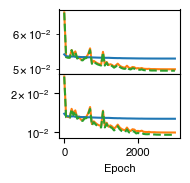

In [28]:
fig, axs = make_canvas(rows=2, cols=1, axes_width_pt=80, axes_aspect=1, sharex=True, gridspec_kw={'hspace': 0})

axs[0].plot(epoch_range, train_loss_cp, color='tab:orange',marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[0].plot(epoch_range, train_loss_naive, color='tab:blue',  marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[0].plot(epoch_range, train_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[0].set_yscale('log')
# axs[0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
# axs[0].yaxis.set_minor_locator(NullLocator()) 
# axs[0].set_ylabel('Train loss')
# axs[0].legend()

axs[1].plot(epoch_range, test_loss_cp, color='tab:orange', marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[1].plot(epoch_range, test_loss_naive, color='tab:blue', marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[1].plot(epoch_range, test_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[1].set_xlabel('Epoch')
axs[1].set_yscale('log')

# enforce ticks at only 0.01 and 0.02
yticks = [0.01, 0.02]
axs[1].yaxis.set_major_locator(FixedLocator(yticks))
# axs[1].yaxis.set_major_formatter(FixedFormatter([f"{t:.2f}" for t in yticks]))
axs[1].yaxis.set_minor_locator(FixedLocator([]))  # remove minor ticks

plt.tight_layout()
plt.savefig('out.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

Compress trainds figures

In [3]:
filename = 'trainds_scaling'
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

seed = data["seed"].astype(np.int64)
d = data["d"].astype(np.float64)
dstop = data["dstop"].astype(np.float64)
test_loss = data["test_loss_orig"].astype(np.float64)
test_loss_cp = data["test_loss_cp"].astype(np.float64)

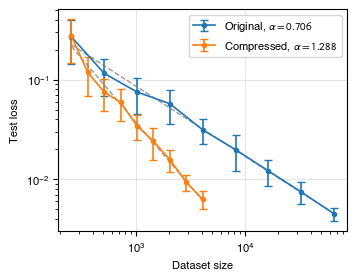

In [11]:
def agg_by(x, y):
    """Aggregate y by unique values of x: return (x_unique, mean, std)."""
    xu, inv = np.unique(x, return_inverse=True)
    means = np.zeros_like(xu, dtype=float)
    stds  = np.zeros_like(xu, dtype=float)
    for i in range(len(xu)):
        yi = y[inv == i]
        means[i] = yi.mean()
        stds[i]  = yi.std(ddof=1) if yi.size > 1 else 0.0
    return xu, means, stds

def fit_powerlaw(x, y):
    """Fit log(y)=a+b log(x); return (a,b) and y_fit on x_sorted."""
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    xs, ys = x[m], y[m]
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    b, a = np.polyfit(np.log(xs), np.log(ys), 1)  # returns slope b, intercept a
    yfit = np.exp(a) * xs**b
    return a, b, xs, yfit

# Aggregate
d_u, tl_mean, tl_std = agg_by(d, test_loss)
ds_u, tlcp_mean, tlcp_std = agg_by(dstop, test_loss_cp)

# fits
a1, b1, x1, y1_fit = fit_powerlaw(d_u, tl_mean)
a2, b2, x2, y2_fit = fit_powerlaw(ds_u, tlcp_mean)

fig, axs = make_canvas(rows=1, cols=1, axes_width_pt=200, axes_aspect=0.75)

# 1) test_loss vs d
axs.errorbar(d_u, tl_mean, yerr=tl_std, fmt='-o', ms=3, capsize=3, lw=1.2, label=rf'Original, $\alpha={-b1:.3f}$')
axs.plot(x1, y1_fit, ls='--', lw=1.0, color='gray', alpha=0.8)
axs.errorbar(ds_u, tlcp_mean, yerr=tlcp_std, fmt='-o', ms=3, capsize=3, lw=1.2, color='tab:orange', label=rf'Compressed, $\alpha={-b2:.3f}$')
axs.plot(x2, y2_fit, ls='--', lw=1.0, color='gray', alpha=0.8)
axs.set_xlabel('Dataset size')
axs.set_ylabel('Test loss')
axs.set_xscale('log')
axs.set_yscale('log')
axs.grid(True, alpha=0.3)
axs.legend()

plt.tight_layout()
plt.show()